# Toxic Clusters Feature Analysis

This notebook analyzes the semantic features of clusters identified in the `examine_roberta_embeddings.ipynb` notebook.

## 0. Preamble

In [1]:
import pandas as pd
import numpy as np

## 1. Load Data

In [2]:
# Load cluster assignments from the embedding analysis notebook
clusters = pd.read_csv('/home/gsc685/acl_metapragmatics/toxic_exploratory_analysis/toxic_cluster_assignments.csv')
print(f"Cluster assignments shape: {clusters.shape}")
print(f"Sources: {clusters['source'].unique()}")
clusters.head()

Cluster assignments shape: (5170, 5)
Sources: ['acl' 'coca']


,token_id,source,source_cluster,joint_cluster,embedding
0,0,acl,2,5,[ 1.88300341e-01 -6.52997242e-03 8.71063247e-...
1,1,acl,1,3,[ 3.34079146e-01 2.13974804e-01 -2.95035690e-...
2,2,acl,1,1,[ 2.41794646e-01 2.57757246e-01 -1.71810940e-...
3,3,acl,7,5,[-1.87376544e-01 1.70035422e-01 -2.37446934e-...
4,4,acl,5,2,[ 3.43040228e-02 -6.95125014e-02 1.51876926e-...


In [3]:
# Load feature data for each source
features_acl = pd.read_csv('/home/gsc685/data/features/acl/toxic_feature_vectors_roberta_buchanan_layer7.csv')
features_acl['source'] = 'acl'

features_coca = pd.read_csv('/home/gsc685/data/features/coca/toxic_feature_vectors_roberta_buchanan_layer7.csv')
features_coca['source'] = 'coca'

print(f"ACL features shape: {features_acl.shape}")
print(f"COCA features shape: {features_coca.shape}")
print(f"\nACL columns: {features_acl.columns.tolist()[:10]}...")
features_acl.head()

ACL features shape: (3773988, 7)
COCA features shape: (3897399, 7)

ACL columns: ['Unnamed: 0', 'cluster', 'feature', 'predicted_value', 'source', 'token_id', 'word']...


,Unnamed: 0,cluster,feature,predicted_value,source,token_id,word
0,0,3,FALSE,0.014602,acl,3339,toxic
1,1,3,TRUE,0.103651,acl,3339,toxic
2,2,3,a,0.690887,acl,3339,toxic
3,3,3,abandon,0.215926,acl,3339,toxic
4,4,3,abdomen,0.051360,acl,3339,toxic


In [4]:
# Load list of infrequent features to exclude
with open('/home/gsc685/data/buchanan_ratings/low_frequency_features_<10.txt', 'r') as f:
    infrequent_features = set(line.strip() for line in f if line.strip())

print(f"Number of infrequent features to exclude: {len(infrequent_features)}")
print(f"Examples: {list(infrequent_features)[:10]}")

Number of infrequent features to exclude: 2608
Examples: ['patriot', 'mr', 'reed', 'aesop', 'clergy', 'introduce', 'proclaim', 'feature', 'assault', 'alter']


In [5]:
# Remove rows with infrequent features
features_acl_filtered = features_acl[~features_acl['feature'].isin(infrequent_features)].copy()
features_coca_filtered = features_coca[~features_coca['feature'].isin(infrequent_features)].copy()

print(f"ACL features after filtering: {features_acl_filtered.shape} (removed {len(features_acl) - len(features_acl_filtered)} rows)")
print(f"COCA features after filtering: {features_coca_filtered.shape} (removed {len(features_coca) - len(features_coca_filtered)} rows)")

ACL features after filtering: (1301604, 7) (removed 2472384 rows)
COCA features after filtering: (1344167, 7) (removed 2553232 rows)


In [6]:
# Combine feature dataframes
features = pd.concat([features_acl_filtered, features_coca_filtered], ignore_index=True)
print(f"Combined features shape: {features.shape}")
features.head()

Combined features shape: (2645771, 7)


,Unnamed: 0,cluster,feature,predicted_value,source,token_id,word
0,0,3,FALSE,0.014602,acl,3339,toxic
1,1,3,TRUE,0.103651,acl,3339,toxic
2,6,3,able,-0.568581,acl,3339,toxic
3,7,3,above,0.217135,acl,3339,toxic
4,18,3,accept,0.193331,acl,3339,toxic


In [7]:
# Join cluster assignments with features on (token_id, source)
# This ensures we match correctly since token_id is only unique within each source
df = features.merge(clusters, on=['token_id', 'source'], how='inner')

print(f"Joined dataframe shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nTokens per source:")
print(df.groupby('source')['token_id'].nunique())
df.head()

Joined dataframe shape: (2645771, 10)

Columns: ['Unnamed: 0', 'cluster', 'feature', 'predicted_value', 'source', 'token_id', 'word', 'source_cluster', 'joint_cluster', 'embedding']

Tokens per source:
source
acl     948
coca    979
Name: token_id, dtype: int64


,Unnamed: 0,cluster,feature,predicted_value,source,token_id,word,source_cluster,joint_cluster,embedding
0,0,3,FALSE,0.014602,acl,3339,toxic,2,5,[ 2.07054377e-01 3.08322698e-01 -1.36267737e-...
1,1,3,TRUE,0.103651,acl,3339,toxic,2,5,[ 2.07054377e-01 3.08322698e-01 -1.36267737e-...
2,6,3,able,-0.568581,acl,3339,toxic,2,5,[ 2.07054377e-01 3.08322698e-01 -1.36267737e-...
3,7,3,above,0.217135,acl,3339,toxic,2,5,[ 2.07054377e-01 3.08322698e-01 -1.36267737e-...
4,18,3,accept,0.193331,acl,3339,toxic,2,5,[ 2.07054377e-01 3.08322698e-01 -1.36267737e-...


## 2. Joint Clustering Regressions

For each joint cluster, run logistic regression models predicting source (COCA vs ACL) from each feature's predicted value. This identifies which semantic features best distinguish between sources within each cluster.

In [8]:
from sklearn.linear_model import LogisticRegression
from scipy import stats

# Pivot features to wide format for regression
# Each row = one token, columns = feature values
feature_matrix = df.pivot_table(
    index=['token_id', 'source'], 
    columns='feature', 
    values='predicted_value'
).reset_index()

# Merge with cluster assignments
feature_matrix = feature_matrix.merge(
    clusters[['token_id', 'source', 'joint_cluster']], 
    on=['token_id', 'source']
)

print(f"Feature matrix shape: {feature_matrix.shape}")
print(f"Joint clusters: {sorted(feature_matrix['joint_cluster'].unique())}")
print(f"\nSamples per cluster:")
print(feature_matrix['joint_cluster'].value_counts().sort_index())
feature_matrix.head()

Feature matrix shape: (1927, 1376)
Joint clusters: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]

Samples per cluster:
joint_cluster
0    265
1    172
2    142
3    305
4    100
5    561
6    181
7     79
8    122
Name: count, dtype: int64


,token_id,source,FALSE,TRUE,able,above,accept,accessory,accident,accomplish,...,wrinkle,write,wrong,year,yell,yellow,young,zip,zoo,joint_cluster
0,0,acl,-0.005713,-0.134814,-0.777841,0.052113,0.273670,0.001840,0.685013,0.086843,...,-0.100184,-2.379829,-0.058227,1.046742,-0.086576,0.308296,0.028429,-0.178790,-0.009021,5
1,1,coca,-0.016113,0.425552,0.031955,-0.029386,0.335167,0.405582,1.045080,-0.191838,...,0.079408,-1.147689,0.163321,0.592042,0.210891,-0.202165,-0.211587,-0.011917,0.452896,5
2,3,coca,0.007592,0.214863,-0.057693,0.313094,0.146359,-0.198855,-0.113977,0.714709,...,-0.181355,-2.283399,0.248727,1.205656,0.101144,-1.114394,-0.100953,-0.070124,-0.296728,5
3,6,coca,-0.022202,-0.031862,0.635233,0.132271,-0.087756,0.380541,0.240807,-0.138935,...,-0.237371,-2.584319,-0.093744,0.885793,-0.481332,-1.061111,-0.069991,-0.068544,-0.427291,3
4,7,coca,-0.017151,0.346491,-0.266274,-0.003545,-0.030858,0.403561,0.248675,-0.047450,...,-0.186001,-2.268295,0.330960,-0.207567,0.338633,-0.195507,-0.642370,0.221133,-0.200353,5


In [9]:
# Get feature columns (exclude metadata columns)
metadata_cols = ['token_id', 'source', 'joint_cluster']
feature_cols = [col for col in feature_matrix.columns if col not in metadata_cols]
print(f"Number of features: {len(feature_cols)}")
print(f"Features: {feature_cols[:20]}...")

Number of features: 1373
Features: ['FALSE', 'TRUE', 'able', 'above', 'accept', 'accessory', 'accident', 'accomplish', 'account', 'achieve', 'acknowledge', 'act', 'add', 'addict', 'admit', 'adult', 'advert', 'advice', 'affect', 'africa']...


In [10]:
# Run logistic regression for each cluster and feature
# Predicting source (1=coca, 0=acl) from feature value

regression_results = []
joint_clusters = sorted(feature_matrix['joint_cluster'].unique())

for cluster in joint_clusters:
    print(f"\nAnalyzing cluster {cluster}...")
    
    # Get data for this cluster
    cluster_data = feature_matrix[feature_matrix['joint_cluster'] == cluster].copy()
    
    # Create binary target: 1 = coca, 0 = acl
    y = (cluster_data['source'] == 'coca').astype(int).values
    n_coca = y.sum()
    n_acl = len(y) - n_coca
    
    print(f"  Cluster {cluster}: n={len(y)} (ACL={n_acl}, COCA={n_coca})")
    
    # Skip if cluster has only one source
    if n_coca == 0 or n_acl == 0:
        print(f"  Skipping cluster {cluster} - only one source present")
        continue
    
    # For each feature, run logistic regression
    for feature_name in feature_cols:
        X = cluster_data[feature_name].values.reshape(-1, 1)
        
        # Skip if no variance
        if X.std() == 0:
            continue
        
        try:
            lr = LogisticRegression(random_state=42, max_iter=1000)
            lr.fit(X, y)
            
            coef = lr.coef_[0][0]
            accuracy = lr.score(X, y)
            
            regression_results.append({
                'joint_cluster': cluster,
                'feature': feature_name,
                'coefficient': coef,
                'accuracy': accuracy,
                'n_samples': len(y),
                'n_coca': n_coca,
                'n_acl': n_acl
            })
        except Exception as e:
            continue

results_df = pd.DataFrame(regression_results)
print(f"\nTotal regression results: {len(results_df)}")
results_df.head()


Analyzing cluster 0...
  Cluster 0: n=265 (ACL=89, COCA=176)

Analyzing cluster 1...
  Cluster 1: n=172 (ACL=157, COCA=15)

Analyzing cluster 2...
  Cluster 2: n=142 (ACL=137, COCA=5)

Analyzing cluster 3...
  Cluster 3: n=305 (ACL=91, COCA=214)

Analyzing cluster 4...
  Cluster 4: n=100 (ACL=90, COCA=10)

Analyzing cluster 5...
  Cluster 5: n=561 (ACL=34, COCA=527)

Analyzing cluster 6...
  Cluster 6: n=181 (ACL=173, COCA=8)

Analyzing cluster 7...
  Cluster 7: n=79 (ACL=79, COCA=0)
  Skipping cluster 7 - only one source present

Analyzing cluster 8...
  Cluster 8: n=122 (ACL=98, COCA=24)

Total regression results: 10984


,joint_cluster,feature,coefficient,accuracy,n_samples,n_coca,n_acl
0,0,FALSE,-0.294501,0.664151,265,176,89
1,0,TRUE,-0.670280,0.664151,265,176,89
2,0,able,0.818630,0.679245,265,176,89
3,0,above,-1.050630,0.664151,265,176,89
4,0,accept,-1.225214,0.671698,265,176,89


In [11]:
# Show top 10 most predictive features for each cluster
# Positive coefficient = higher feature value predicts COCA
# Negative coefficient = higher feature value predicts ACL

print("=" * 80)
print("TOP 10 FEATURES PREDICTING SOURCE FOR EACH JOINT CLUSTER")
print("(Positive coef = predicts COCA, Negative coef = predicts ACL)")
print("=" * 80)

for cluster in joint_clusters:
    cluster_results = results_df[results_df['joint_cluster'] == cluster].copy()
    
    if len(cluster_results) == 0:
        print(f"\nCluster {cluster}: No results (single source)")
        continue
    
    cluster_results['abs_coef'] = cluster_results['coefficient'].abs()
    top_features = cluster_results.nlargest(10, 'abs_coef')
    
    n_samples = top_features.iloc[0]['n_samples']
    n_coca = top_features.iloc[0]['n_coca']
    n_acl = top_features.iloc[0]['n_acl']
    
    print(f"\nCluster {cluster} (n={n_samples}, ACL={n_acl}, COCA={n_coca}):")
    print(top_features[['feature', 'coefficient', 'accuracy']].to_string(index=False))

TOP 10 FEATURES PREDICTING SOURCE FOR EACH JOINT CLUSTER
(Positive coef = predicts COCA, Negative coef = predicts ACL)

Cluster 0 (n=265, ACL=89, COCA=176):
 feature  coefficient  accuracy
    comb     2.865239  0.675472
function    -2.716724  0.679245
    fake    -2.653617  0.683019
 compose     2.499885  0.667925
  murder     2.472739  0.701887
    roof     2.458406  0.720755
converse    -2.397687  0.664151
    pack     2.332493  0.667925
   rhyme    -2.298607  0.683019
     box     2.289636  0.735849

Cluster 1 (n=172, ACL=157, COCA=15):
feature  coefficient  accuracy
violent    -1.944257  0.912791
 affect    -1.788676  0.912791
 please    -1.775485  0.912791
  brick     1.713072  0.912791
   roof     1.628948  0.912791
  state    -1.542219  0.918605
 bullet     1.524401  0.912791
 second     1.523673  0.912791
  sixty     1.509959  0.912791
possess     1.450178  0.912791

Cluster 2 (n=142, ACL=137, COCA=5):
feature  coefficient  accuracy
  cause    -2.117721  0.964789
  cream     1

In [12]:
# Save regression results
output_path = '/home/gsc685/acl_metapragmatics/toxic_exploratory_analysis/toxic_joint_cluster_regression_results.csv'
results_df.to_csv(output_path, index=False)
print(f"Results saved to: {output_path}")

Results saved to: /home/gsc685/acl_metapragmatics/toxic_exploratory_analysis/toxic_joint_cluster_regression_results.csv


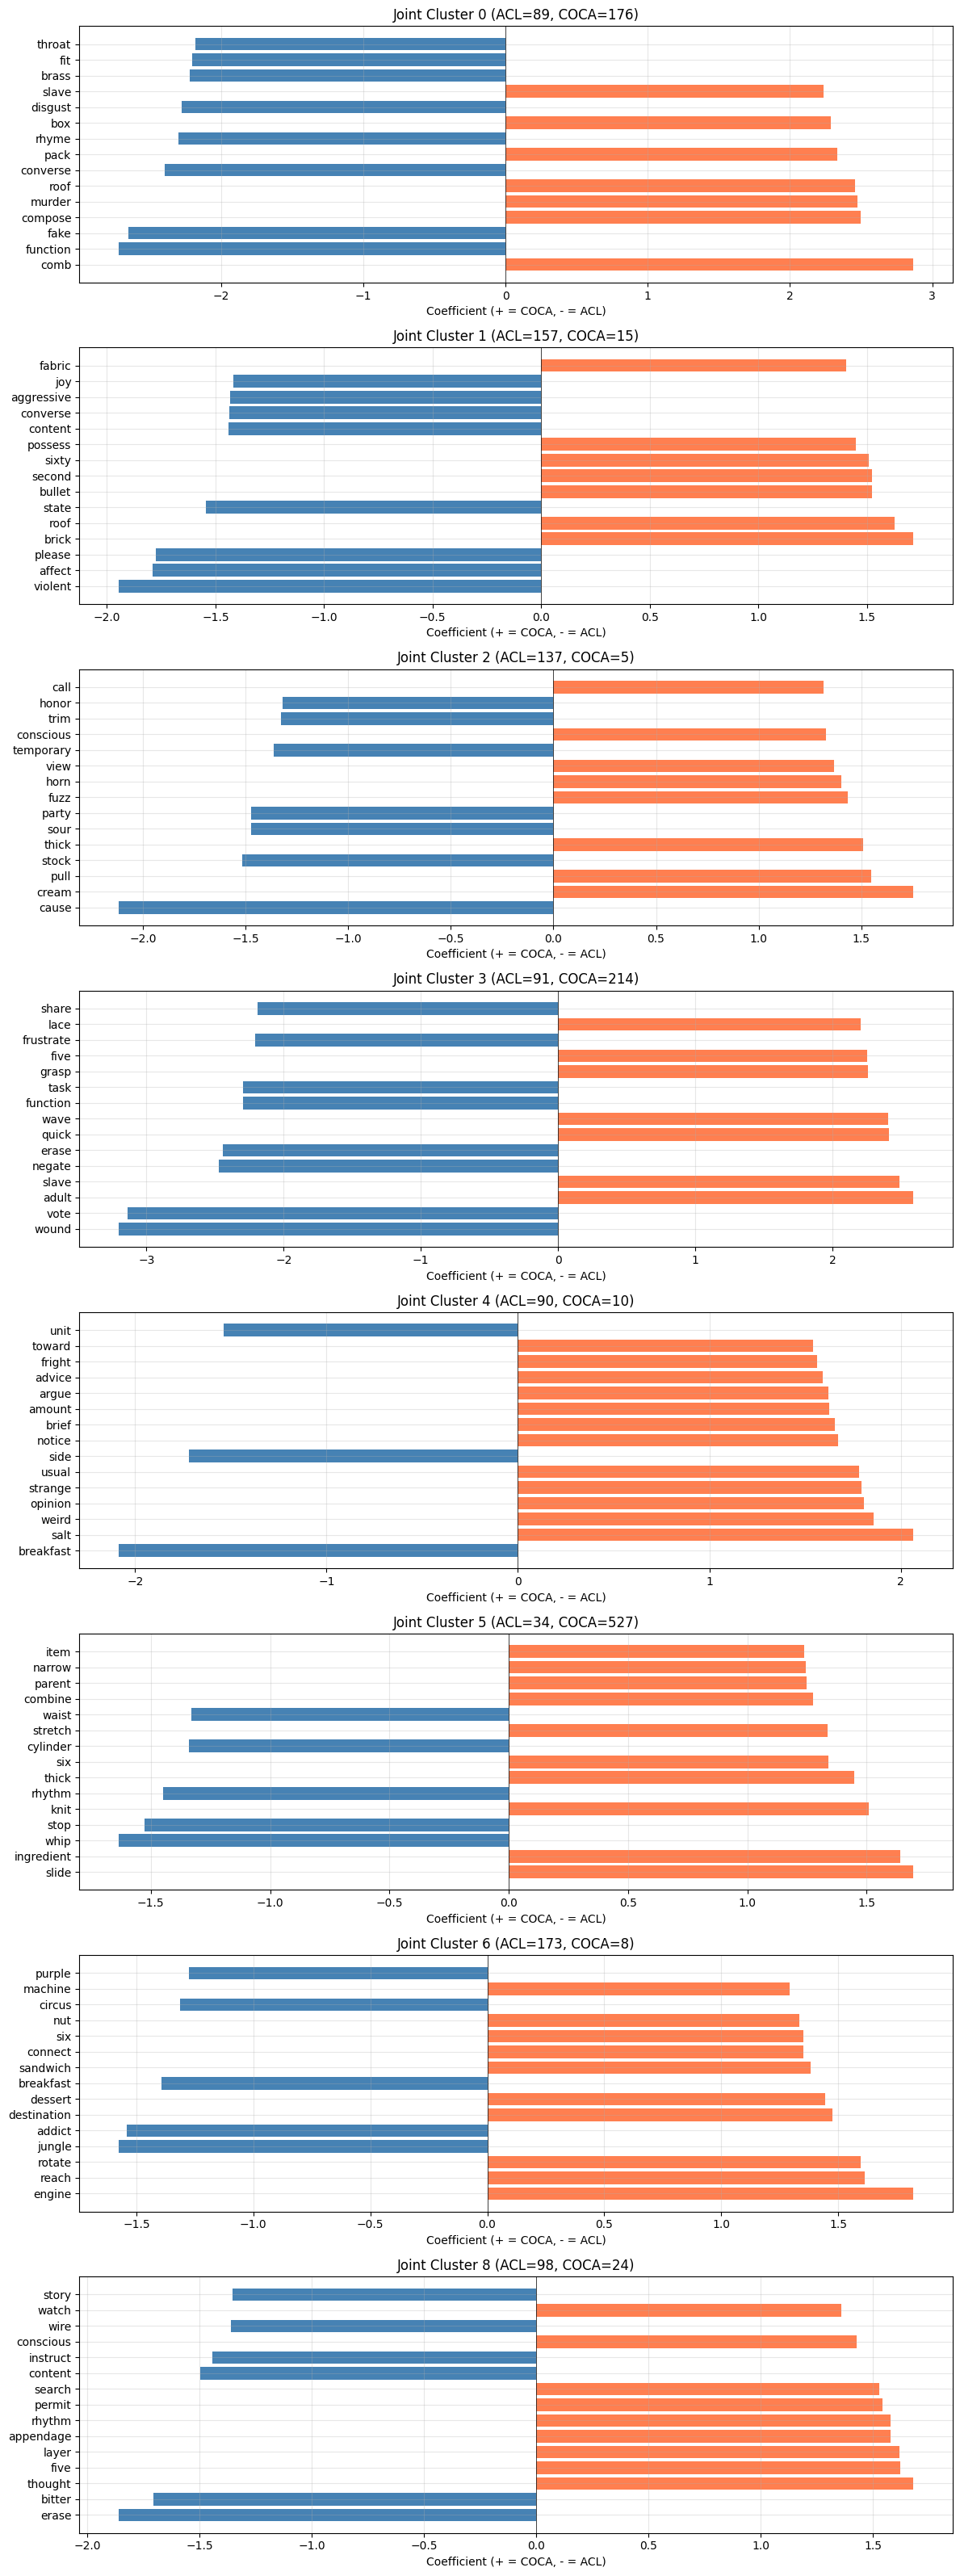

Visualization saved.


In [13]:
# Visualization: Top features by cluster
import matplotlib.pyplot as plt

# Only plot clusters with both sources
clusters_with_both = results_df['joint_cluster'].unique()

fig, axes = plt.subplots(len(clusters_with_both), 1, figsize=(12, 4*len(clusters_with_both)))

if len(clusters_with_both) == 1:
    axes = [axes]

for idx, cluster in enumerate(sorted(clusters_with_both)):
    ax = axes[idx]
    
    cluster_results = results_df[results_df['joint_cluster'] == cluster].copy()
    cluster_results['abs_coef'] = cluster_results['coefficient'].abs()
    top_15 = cluster_results.nlargest(15, 'abs_coef')
    
    colors = ['coral' if c > 0 else 'steelblue' for c in top_15['coefficient']]
    ax.barh(range(len(top_15)), top_15['coefficient'], color=colors)
    ax.set_yticks(range(len(top_15)))
    ax.set_yticklabels(top_15['feature'])
    ax.set_xlabel('Coefficient (+ = COCA, - = ACL)')
    ax.set_title(f'Joint Cluster {cluster} (ACL={int(top_15.iloc[0]["n_acl"])}, COCA={int(top_15.iloc[0]["n_coca"])})')
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/home/gsc685/acl_metapragmatics/toxic_exploratory_analysis/toxic_joint_cluster_top_features.png', dpi=150, bbox_inches='tight')
plt.show()

print("Visualization saved.")

## 3. Cluster vs All Others Regressions

For each joint cluster, run logistic regression models predicting cluster membership (this cluster vs all other clusters) from each feature's predicted value. This identifies which semantic features best distinguish each cluster from the rest, regardless of source.

In [14]:
# Run logistic regression for each cluster vs all others
# Predicting cluster membership (1=in cluster, 0=not in cluster) from feature value

cluster_vs_all_results = []
joint_clusters = sorted(feature_matrix['joint_cluster'].unique())

for cluster in joint_clusters:
    print(f"\nAnalyzing cluster {cluster} vs all others...")
    
    # Create binary target: 1 = in this cluster, 0 = in any other cluster
    y = (feature_matrix['joint_cluster'] == cluster).astype(int).values
    n_in_cluster = y.sum()
    n_other = len(y) - n_in_cluster
    
    print(f"  Cluster {cluster}: n_in={n_in_cluster}, n_other={n_other}")
    
    # For each feature, run logistic regression
    for feature_name in feature_cols:
        X = feature_matrix[feature_name].values.reshape(-1, 1)
        
        # Skip if no variance
        if X.std() == 0:
            continue
        
        try:
            lr = LogisticRegression(random_state=42, max_iter=1000)
            lr.fit(X, y)
            
            coef = lr.coef_[0][0]
            accuracy = lr.score(X, y)
            
            cluster_vs_all_results.append({
                'joint_cluster': cluster,
                'feature': feature_name,
                'coefficient': coef,
                'accuracy': accuracy,
                'n_in_cluster': n_in_cluster,
                'n_other': n_other,
                'n_total': len(y)
            })
        except Exception as e:
            continue

cluster_vs_all_df = pd.DataFrame(cluster_vs_all_results)
print(f"\nTotal regression results: {len(cluster_vs_all_df)}")
cluster_vs_all_df.head()


Analyzing cluster 0 vs all others...
  Cluster 0: n_in=265, n_other=1662

Analyzing cluster 1 vs all others...
  Cluster 1: n_in=172, n_other=1755



Analyzing cluster 2 vs all others...
  Cluster 2: n_in=142, n_other=1785

Analyzing cluster 3 vs all others...
  Cluster 3: n_in=305, n_other=1622

Analyzing cluster 4 vs all others...
  Cluster 4: n_in=100, n_other=1827

Analyzing cluster 5 vs all others...
  Cluster 5: n_in=561, n_other=1366

Analyzing cluster 6 vs all others...
  Cluster 6: n_in=181, n_other=1746

Analyzing cluster 7 vs all others...
  Cluster 7: n_in=79, n_other=1848

Analyzing cluster 8 vs all others...
  Cluster 8: n_in=122, n_other=1805

Total regression results: 12357


,joint_cluster,feature,coefficient,accuracy,n_in_cluster,n_other,n_total
0,0,FALSE,0.535760,0.862481,265,1662,1927
1,0,TRUE,0.541483,0.862481,265,1662,1927
2,0,able,0.880024,0.862481,265,1662,1927
3,0,above,0.479058,0.862481,265,1662,1927
4,0,accept,0.867920,0.862481,265,1662,1927


In [15]:
# Show top 10 most predictive features for each cluster vs all others
# Positive coefficient = higher feature value predicts membership in this cluster
# Negative coefficient = higher feature value predicts membership in other clusters

print("=" * 80)
print("TOP 10 FEATURES PREDICTING CLUSTER MEMBERSHIP (vs ALL OTHER CLUSTERS)")
print("(Positive coef = predicts THIS cluster, Negative coef = predicts OTHER clusters)")
print("=" * 80)

for cluster in joint_clusters:
    cluster_results = cluster_vs_all_df[cluster_vs_all_df['joint_cluster'] == cluster].copy()
    cluster_results['abs_coef'] = cluster_results['coefficient'].abs()
    top_features = cluster_results.nlargest(10, 'abs_coef')
    
    n_in = top_features.iloc[0]['n_in_cluster']
    n_other = top_features.iloc[0]['n_other']
    
    print(f"\nCluster {cluster} (n={n_in}) vs Others (n={n_other}):")
    print(top_features[['feature', 'coefficient', 'accuracy']].to_string(index=False))

TOP 10 FEATURES PREDICTING CLUSTER MEMBERSHIP (vs ALL OTHER CLUSTERS)
(Positive coef = predicts THIS cluster, Negative coef = predicts OTHER clusters)

Cluster 0 (n=265) vs Others (n=1662):
 feature  coefficient  accuracy
  origin    -6.157596  0.862481
document    -5.882619  0.862481
 finance     4.997331  0.861443
    deal     4.310555  0.862481
   fresh    -4.243410  0.862481
   adult     3.883264  0.862481
  theory    -3.784653  0.862481
   grave    -3.588137  0.861962
     ink    -3.403978  0.862481
  regret     3.402677  0.864556

Cluster 1 (n=172) vs Others (n=1755):
 feature  coefficient  accuracy
    rope     5.461710  0.910223
continue    -4.983219  0.910742
schedule    -4.373771  0.910742
   stalk     4.356522  0.910742
    comb    -4.043272  0.910223
   crisp    -3.942937  0.910742
   rhyme     3.889548  0.910742
   guard     3.877260  0.910742
     pit     3.473864  0.910742
   swamp     3.461600  0.910742

Cluster 2 (n=142) vs Others (n=1785):
  feature  coefficient  accu

In [16]:
# Save cluster vs all results
output_path = '/home/gsc685/acl_metapragmatics/toxic_exploratory_analysis/toxic_cluster_vs_all_regression_results.csv'
cluster_vs_all_df.to_csv(output_path, index=False)
print(f"Results saved to: {output_path}")

Results saved to: /home/gsc685/acl_metapragmatics/toxic_exploratory_analysis/toxic_cluster_vs_all_regression_results.csv


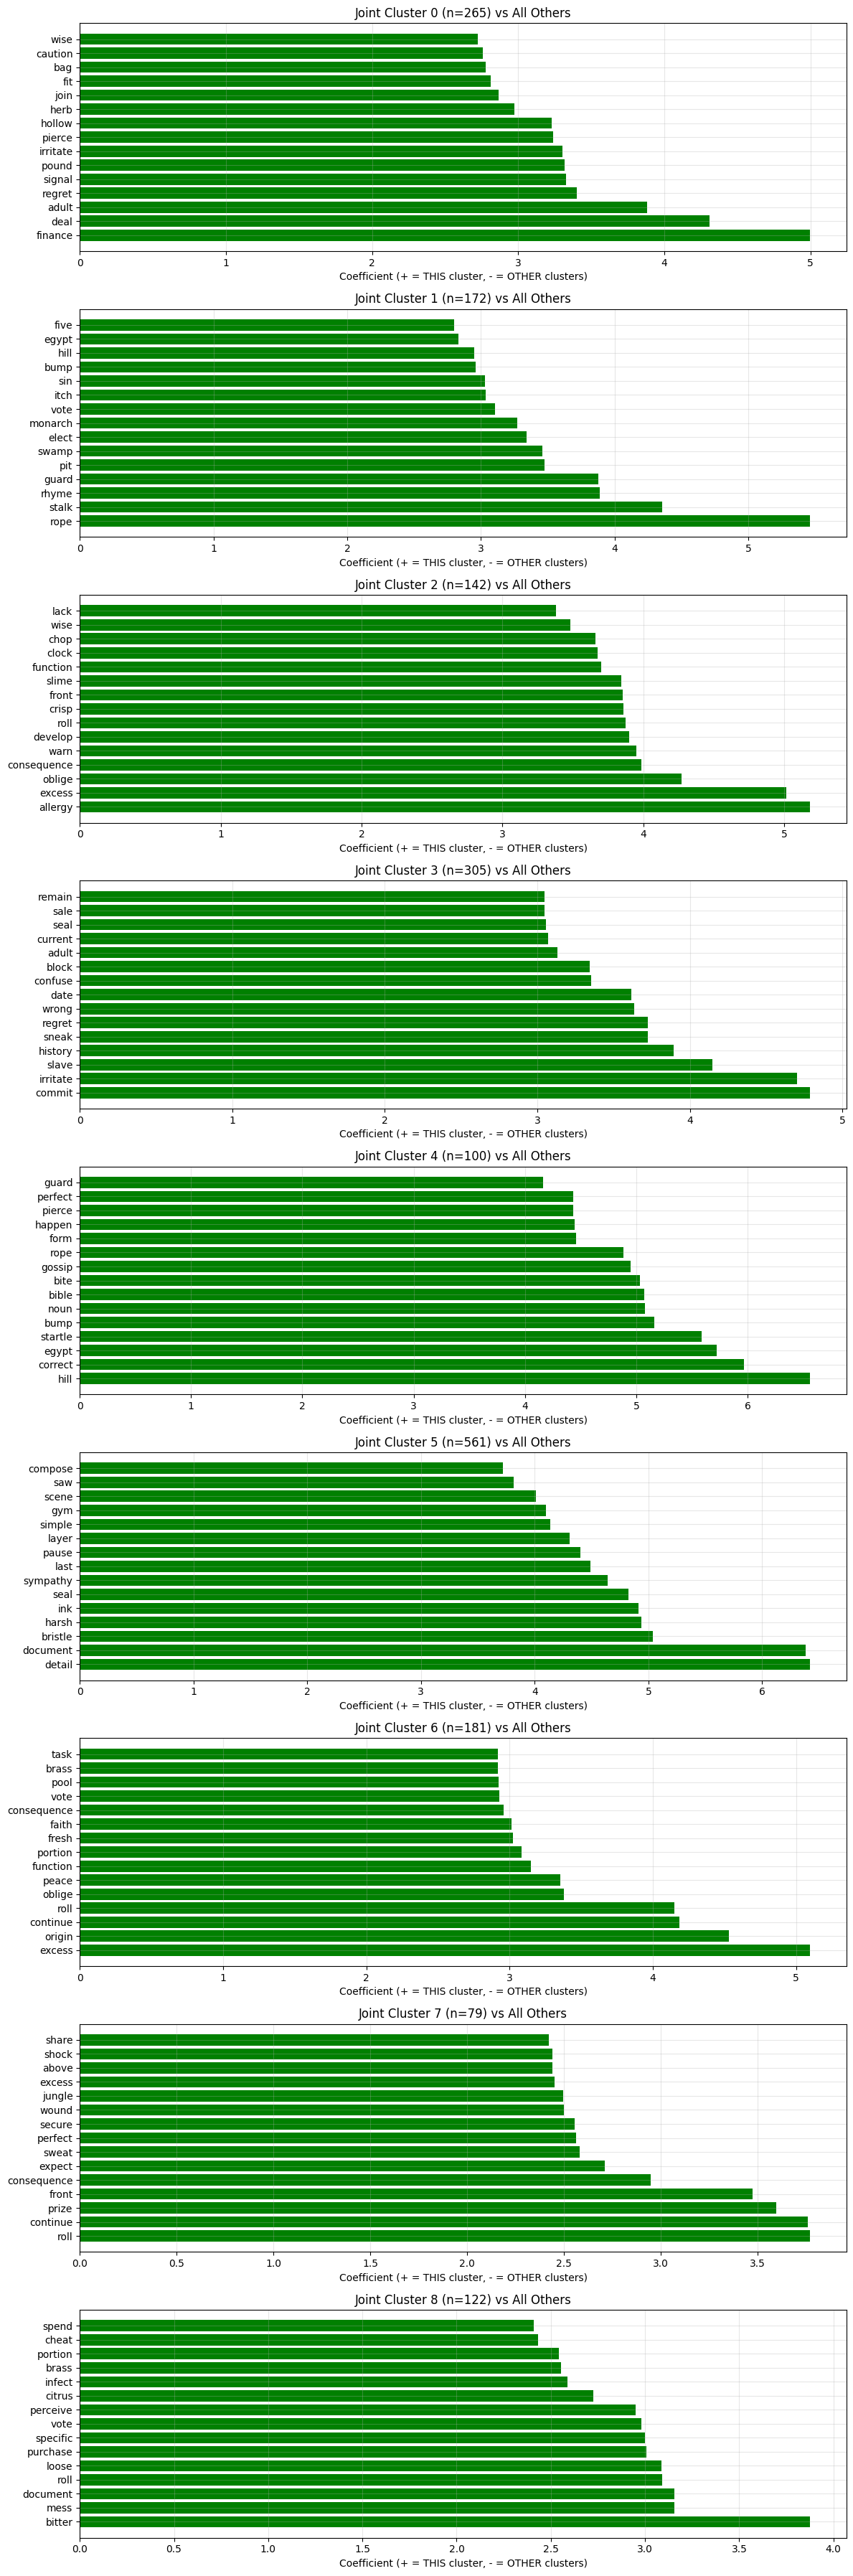

Visualization saved.


In [17]:
# Visualization: Top features for each cluster vs all others
fig, axes = plt.subplots(len(joint_clusters), 1, figsize=(12, 4*len(joint_clusters)))

if len(joint_clusters) == 1:
    axes = [axes]

for idx, cluster in enumerate(joint_clusters):
    ax = axes[idx]
    
    cluster_results = cluster_vs_all_df[cluster_vs_all_df['joint_cluster'] == cluster].copy()
    cluster_results['abs_coef'] = cluster_results['coefficient'].abs()
    top_15 = cluster_results.nlargest(15, 'coefficient')
    
    colors = ['green' if c > 0 else 'purple' for c in top_15['coefficient']]
    ax.barh(range(len(top_15)), top_15['coefficient'], color=colors)
    ax.set_yticks(range(len(top_15)))
    ax.set_yticklabels(top_15['feature'])
    ax.set_xlabel('Coefficient (+ = THIS cluster, - = OTHER clusters)')
    ax.set_title(f'Joint Cluster {cluster} (n={int(top_15.iloc[0]["n_in_cluster"])}) vs All Others')
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/home/gsc685/acl_metapragmatics/toxic_exploratory_analysis/toxic_cluster_vs_all_top_features.png', dpi=150, bbox_inches='tight')
plt.show()

print("Visualization saved.")

In [18]:
# Load original sentence data to display sample sentences per cluster
acl_tokens = pd.read_csv('/home/gsc685/data/collected_tokens/acl/toxic.csv')
acl_tokens['source'] = 'acl'
acl_tokens = acl_tokens.rename(columns={acl_tokens.columns[0]: 'token_id'})

coca_tokens = pd.read_csv('/home/gsc685/data/collected_tokens/coca/toxic.csv')
coca_tokens['source'] = 'coca'
coca_tokens = coca_tokens.rename(columns={coca_tokens.columns[0]: 'token_id'})

tokens = pd.concat([acl_tokens, coca_tokens], ignore_index=True)

# Merge with cluster assignments
tokens_with_clusters = tokens.merge(clusters[['token_id', 'source', 'joint_cluster']], on=['token_id', 'source'])

print(f"Tokens with clusters: {len(tokens_with_clusters)}")
tokens_with_clusters.head()

Tokens with clusters: 5170


,token_id,corpus_id,sentence,start_idx,end_idx,source,joint_cluster
0,0,14382934,We then expanded the coverage to less well kno...,21,22,acl,5
1,1,247958012,"2021 ), using large language models for data a...",23,24,acl,3
2,2,248780022,2021) detect toxic language in a user utteranc...,3,4,acl,1
3,3,15424937,"After spawning, the fish die in their thousand...",11,12,acl,5
4,4,645466,The identification of fertile translations is ...,44,45,acl,2


In [19]:
# Sample sentences from each joint cluster
print("=" * 80)
print("SAMPLE SENTENCES FROM EACH JOINT CLUSTER")
print("=" * 80)

for cluster in sorted(tokens_with_clusters['joint_cluster'].unique()):
    cluster_data = tokens_with_clusters[tokens_with_clusters['joint_cluster'] == cluster]
    n_acl = (cluster_data['source'] == 'acl').sum()
    n_coca = (cluster_data['source'] == 'coca').sum()
    
    print(f"\n{'='*80}")
    print(f"CLUSTER {cluster} (n={len(cluster_data)}, ACL={n_acl}, COCA={n_coca})")
    print(f"{'='*80}")
    
    # Sample 5 sentences (or fewer if cluster is smaller)
    sample = cluster_data.sample(n=min(5, len(cluster_data)), random_state=42)
    
    for i, (_, row) in enumerate(sample.iterrows(), 1):
        source = row['source'].upper()
        sentence = row['sentence'][:200] + '...' if len(row['sentence']) > 200 else row['sentence']
        print(f"\n  [{source}] {sentence}")

SAMPLE SENTENCES FROM EACH JOINT CLUSTER

CLUSTER 0 (n=567, ACL=372, COCA=195)

  [COCA] That 's a primary takeaway of the research on poverty : part of what makes poverty toxic may be the lack of control over what 's happening to you . #

  [COCA] @!KIRSTEN-GILLIBRAND# And you just heard from these victims , there are too many command climates that are toxic .

  [ACL] Online abuse can inflict harm on users and communities, making online spaces unsafe and toxic.

  [COCA] And it truly is , you know , it 's ... @!MIKE-MYERS# It 's a toxic - I would say it 's the industrial disease of creativity .

  [COCA] The moves this past week may not simplify Matheny 's call but so far it 's turned parts of the bullpen from toxic to electric .

CLUSTER 1 (n=735, ACL=717, COCA=18)

  [ACL] The main contributions of this work are the following: • We addressed for the second time the task of unsupervised civil rephrases of toxic texts, relying for the first time on the Civil Comments data...

  [ACL]

## 4. Average Feature Values by Cluster

Compute simple averages of feature values for each cluster, separately for ACL and COCA sources.

In [20]:
# Compute average feature values for each cluster, separately by source
# Using the df dataframe which has features joined with cluster assignments

# ACL averages by cluster
acl_cluster_means = df[df['source'] == 'acl'].groupby(['joint_cluster', 'feature'])['predicted_value'].mean().reset_index()
acl_cluster_means = acl_cluster_means.pivot(index='feature', columns='joint_cluster', values='predicted_value')
acl_cluster_means.columns = [f'cluster_{c}' for c in acl_cluster_means.columns]

print("ACL - Average Feature Values by Cluster")
print(f"Shape: {acl_cluster_means.shape}")
print(acl_cluster_means.head(10))

ACL - Average Feature Values by Cluster
Shape: (1373, 9)
            cluster_0  cluster_1  cluster_2  cluster_3  cluster_4  cluster_5  \
feature                                                                        
FALSE        0.001030  -0.008131  -0.005043  -0.006333  -0.011534   0.005343   
TRUE         0.254656   0.297747   0.177448   0.244726   0.233973  -0.055913   
able         0.175211   0.058842   0.232832   0.137315   0.245067   0.060295   
above        0.161186   0.141809   0.170168   0.122274   0.057075   0.096927   
accept       0.320760   0.192270   0.133907   0.131699   0.291575  -0.009590   
accessory    0.142590   0.057834   0.241471   0.381578  -0.131274   0.258378   
accident     0.042685   0.197435   0.197275   0.238049  -0.089549   0.373920   
accomplish   0.120085   0.055670   0.125264   0.063083   0.024199   0.072904   
account     -0.059037  -0.124733   0.153857  -0.043552  -0.096875   0.002295   
achieve      0.004556   0.051394   0.136136  -0.138615   0.0577

In [21]:
# COCA averages by cluster
coca_cluster_means = df[df['source'] == 'coca'].groupby(['joint_cluster', 'feature'])['predicted_value'].mean().reset_index()
coca_cluster_means = coca_cluster_means.pivot(index='feature', columns='joint_cluster', values='predicted_value')
coca_cluster_means.columns = [f'cluster_{c}' for c in coca_cluster_means.columns]

print("COCA - Average Feature Values by Cluster")
print(f"Shape: {coca_cluster_means.shape}")
print(coca_cluster_means.head(10))

COCA - Average Feature Values by Cluster
Shape: (1373, 8)
            cluster_0  cluster_1  cluster_2  cluster_3  cluster_4  cluster_5  \
feature                                                                        
FALSE       -0.004079  -0.008856  -0.013480  -0.008709  -0.025488   0.001388   
TRUE         0.195992   0.198108   0.229063   0.217214   0.146829  -0.019011   
able         0.326803   0.149545   0.644717   0.173818   0.216614   0.098277   
above        0.112707   0.117923  -0.017788   0.076465   0.112062   0.086275   
accept       0.167238   0.280779  -0.146913   0.147055   0.485695   0.032896   
accessory    0.166354   0.190329   0.246826   0.335102  -0.051055   0.281929   
accident     0.026936   0.270995   0.046867   0.264020  -0.087050   0.181018   
accomplish   0.015992  -0.045234  -0.018426  -0.051913  -0.052745   0.065609   
account     -0.062652  -0.140667   0.000836  -0.043721  -0.112371  -0.064864   
achieve     -0.146479  -0.106722   0.015135  -0.276893  -0.237

In [22]:
# Display top 10 features with highest average values for each cluster (ACL)
print("=" * 80)
print("ACL - TOP 10 FEATURES BY AVERAGE VALUE FOR EACH CLUSTER")
print("=" * 80)

for col in acl_cluster_means.columns:
    cluster_num = col.replace('cluster_', '')
    top_features = acl_cluster_means[col].nlargest(10)
    print(f"\n{col}:")
    for feature, value in top_features.items():
        print(f"  {feature}: {value:.4f}")

ACL - TOP 10 FEATURES BY AVERAGE VALUE FOR EACH CLUSTER

cluster_0:
  person: 6.2322
  hurt: 4.6807
  grow: 4.2703
  good: 4.0203
  bad: 3.7773
  eat: 3.6733
  color: 3.4089
  water: 3.0554
  feel: 3.0136
  smart: 2.9542

cluster_1:
  person: 6.6665
  color: 5.1007
  grow: 4.5553
  water: 4.3843
  good: 4.1676
  act: 3.8285
  bad: 3.7759
  hurt: 3.6839
  place: 3.2211
  plant: 3.0764

cluster_2:
  person: 6.9901
  color: 6.9876
  hurt: 6.3210
  bad: 4.2500
  act: 4.2012
  animal: 4.1461
  good: 4.0315
  human: 3.6636
  water: 3.5547
  money: 3.4607

cluster_3:
  person: 6.3531
  color: 4.8463
  hurt: 4.4791
  bad: 3.8732
  feel: 3.8129
  good: 3.3057
  word: 2.4982
  act: 2.4506
  grow: 2.4480
  sad: 2.4318

cluster_4:
  person: 5.2555
  grow: 4.8337
  plant: 4.1859
  eat: 3.7448
  water: 3.3980
  small: 3.3822
  up: 2.9519
  place: 2.9183
  act: 2.9059
  tree: 2.7395

cluster_5:
  color: 5.7770
  act: 4.5585
  person: 4.0454
  hurt: 4.0354
  bad: 3.7051
  good: 3.5720
  fruit: 2.9001


In [23]:
# Display top 10 features with highest average values for each cluster (COCA)
print("=" * 80)
print("COCA - TOP 10 FEATURES BY AVERAGE VALUE FOR EACH CLUSTER")
print("=" * 80)

for col in coca_cluster_means.columns:
    cluster_num = col.replace('cluster_', '')
    top_features = coca_cluster_means[col].nlargest(10)
    print(f"\n{col}:")
    for feature, value in top_features.items():
        print(f"  {feature}: {value:.4f}")

COCA - TOP 10 FEATURES BY AVERAGE VALUE FOR EACH CLUSTER

cluster_0:
  person: 4.0895
  hurt: 3.8698
  water: 3.8610
  good: 3.8260
  bad: 3.7092
  animal: 3.6375
  feel: 3.5005
  grow: 3.2601
  color: 3.0853
  leg: 3.0389

cluster_1:
  person: 7.8945
  color: 5.3278
  grow: 4.5251
  water: 4.1271
  eat: 3.2940
  act: 3.2874
  plant: 3.2782
  place: 3.1037
  good: 3.0527
  bad: 3.0464

cluster_2:
  color: 7.2510
  animal: 4.7138
  hurt: 4.2826
  leg: 3.9178
  person: 3.6891
  bad: 3.3960
  smart: 3.3559
  grow: 3.1315
  comfort: 2.8138
  good: 2.8078

cluster_3:
  person: 5.2611
  color: 4.4973
  bad: 4.0441
  feel: 3.7552
  hurt: 3.2244
  good: 3.0698
  animal: 2.8533
  leg: 2.6789
  place: 2.5171
  smell: 2.4332

cluster_4:
  water: 5.8420
  person: 5.1061
  grow: 4.8162
  eat: 4.7590
  color: 4.1007
  act: 4.0818
  place: 3.8633
  plant: 3.7170
  small: 3.6651
  leg: 3.5544

cluster_5:
  color: 5.0785
  bad: 3.3940
  hurt: 3.3359
  good: 3.1882
  act: 3.1341
  person: 2.4595
  fruit

In [24]:
# Save average feature values to CSV files
acl_output_path = '/home/gsc685/acl_metapragmatics/toxic_exploratory_analysis/toxic_cluster_feature_averages_acl.csv'
coca_output_path = '/home/gsc685/acl_metapragmatics/toxic_exploratory_analysis/toxic_cluster_feature_averages_coca.csv'

acl_cluster_means.to_csv(acl_output_path)
coca_cluster_means.to_csv(coca_output_path)

print(f"ACL averages saved to: {acl_output_path}")
print(f"COCA averages saved to: {coca_output_path}")

ACL averages saved to: /home/gsc685/acl_metapragmatics/toxic_exploratory_analysis/toxic_cluster_feature_averages_acl.csv
COCA averages saved to: /home/gsc685/acl_metapragmatics/toxic_exploratory_analysis/toxic_cluster_feature_averages_coca.csv
